In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jax

import sys
sys.path.append('../')
# ── Step 0: Load the JAX emulator (one-time, takes ~2 seconds for JIT warm-up)
from CEmulator.jax.jax_emulator import JAXEmulator

print("Loading JAX emulator...")
emu = JAXEmulator(verbose=False)
print("Done.\n")

Loading JAX emulator...
Done.



2. Linear Power Spectrum P_lin(k, z)


Text(0, 0.5, 'P(k) [(Mpc/h)^3]')

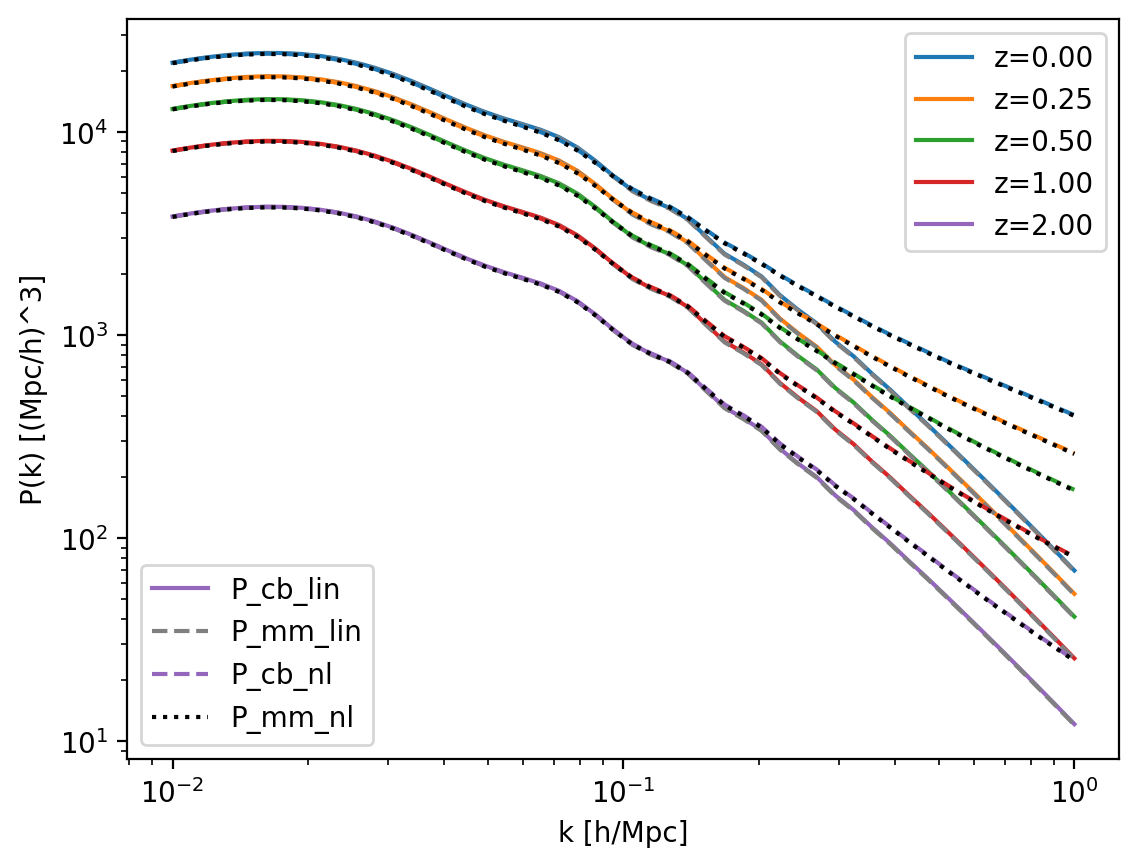

In [7]:
cosmo = jnp.array([
    0.049,   # Omega_b   — baryon density
    0.313,   # Omega_m   — total CDM + baryon density (NO neutrinos)
    67.66,   # H0        — Hubble constant [km/s/Mpc]
    0.9665,  # n_s       — scalar spectral index
    2.105,   # A_s × 10^9 — primordial power amplitude
    -1.0,    # w_0       — dark energy EoS (ΛCDM)
    0.0,     # w_a       — dark energy EoS evolution (ΛCDM)
    0.06,    # Sum m_nu  — neutrino mass sum [eV]
])

z = jnp.array([0.0, 0.25, 0.5, 1.0, 2.0])   # redshifts
k = jnp.logspace(-2, 0, 50)                   # wavenumbers [h/Mpc]

# ── Step 2: Predict linear power spectrum ──────────────────────────────

print("=" * 60)
print("2. Linear Power Spectrum P_lin(k, z)")
print("=" * 60)

# P_cb(k,z) — only CDM+baryon (cb) component, no neutrinos
p_cb = emu.get_pkcblin(cosmo, z, k)
# P_total(k,z) — total matter (cb + massive neutrinos)
p_mm = emu.get_pklin(cosmo, z, k, Pcb=False)

pncb = emu.get_pknl(cosmo, z, k, Pcb=True)
pnmm = emu.get_pknl(cosmo, z, k, Pcb=False)

for i in range(len(z)):
    l0, = plt.plot(k, p_cb[i], label=f"z={z[i]:.2f}")
    l1, = plt.plot(k, p_mm[i], linestyle="--", color='gray')
    l2, = plt.plot(k, pncb[i], linestyle="--", color=l0.get_color())
    l3, = plt.plot(k, pnmm[i], linestyle=":", color='k')

leg1 = plt.legend()
leg2 = plt.legend([l0, l1, l2, l3], ["P_cb_lin", "P_mm_lin", "P_cb_nl", "P_mm_nl"], loc="lower left")
plt.gca().add_artist(leg1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("k [h/Mpc]")
plt.ylabel("P(k) [(Mpc/h)^3]")

In [8]:
from CEmulator.Emulator import Pkmm_CEmulator

emu_np = Pkmm_CEmulator()
emu_np.set_cosmos(
    Omegab=0.049, Omegac=0.264,   # Omega_b, Omega_c = Omega_m - Omega_b
    H0=67.66, As=2.105e-9, ns=0.9665,
    w=-1.0, wa=0.0, mnu=0.06,
)

# Convert to numpy for fair comparison
z_np = np.asarray(z)
k_np = np.asarray(k)

pk_np = emu_np.get_pknl(z_np, k_np, lintype='Emulator', nltype='hmcode2020', Pcb=True)
pk_jax = np.asarray(emu.get_pknl(cosmo, z, k, nltype='hmcode2020', Pcb=True))

rel_diff = np.max(np.abs(pk_jax - pk_np) / pk_np)
print(f"   JAX vs numpy get_pknl(hmcode2020): max relative diff = {rel_diff:.4e}")

   JAX vs numpy get_pknl(hmcode2020): max relative diff = 4.5525e-10


In [18]:
def pknl_jax(cosmo):
    return emu.get_pknl(cosmo, z=z, k=k)[0,0]
grad_pk = jax.grad(pknl_jax)(cosmo)

In [19]:
grad_pk

Array([  1790.05822747, -67524.31922556,    171.08115009, -43699.16548476,
        10438.49830574, -10959.33715869,  -3543.59084532,  -4268.28168234],      dtype=float64)